# Costing a simulation against a tariff contract

`openenergyid.simeval` can already monetise a simulation, but only from
`price_electricity_delivered` / `price_electricity_exported` columns the caller supplies:
a flat volume x price product. That misses everything structural about a real bill --
the capacity tariff, distribution and transmission, fixed fees, excise, the energy fund,
VAT and injection tariffs.

`openenergyid.cost` costs a simulation against a full tariff contract instead, using
[energy-cost](https://github.com/EnergieID/energy-cost). Pass a contract via
`FullSimulationInput.cost` (an `openenergyid.cost.ContractCostSettings`) and the summary
gains a `cost` section with the bill before, the bill after, and the savings broken down
by component.

The two mechanisms are mutually exclusive: supplying both a contract and price columns
is a validation error, because there would be no way to know which the caller meant.

In [1]:
import copy
import datetime as dt
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
from energy_cost.index import CachedIndex, DataFrameIndex, EntsoeDayAheadIndex, Index

from openenergyid.sim import FullSimulationInput, run_simulation

## 1. Register a price index

A dynamic tariff refers to a price index *by name*. `energy_cost` resolves that name from
a process-global registry at calculation time, so the index has to be registered up front
-- an unregistered name raises `KeyError` deep inside the calculation.

We use the real quarter-hourly Belgian day-ahead price when an ENTSO-E API key is
available, and fall back to a synthetic daily sine so this notebook runs offline. The
shape matters: a battery earns its keep by shifting load in *time*, so a monthly-average
index would hide most of its value.

In [2]:
INDEX_NAME = "Belpex15min"


def entsoe_api_key() -> str | None:
    """Look for an ENTSO-E key in the environment or in secrets.json."""
    if key := os.environ.get("ENTSOE_API_KEY"):
        return key
    secrets = Path("secrets.json")
    if secrets.exists():
        return json.loads(secrets.read_text()).get("ENTSOE_APIKEY")
    return None


api_key = entsoe_api_key()
if api_key:
    Index.register(
        INDEX_NAME,
        CachedIndex(
            EntsoeDayAheadIndex("BE", api_key=api_key, resolution=dt.timedelta(minutes=15)),
            # An explicit file_name is required: CachedIndex otherwise picks a random one
            # and silently re-downloads everything on each run.
            file_name="belpex15min",
        ),
    )
    print(f"Registered {INDEX_NAME} from ENTSO-E (real day-ahead prices)")
else:
    stamps = pd.date_range("2023-12-01", "2025-02-01", freq="15min", tz="Europe/Brussels")
    Index.register(
        INDEX_NAME,
        DataFrameIndex(
            pd.DataFrame(
                {
                    "timestamp": stamps,
                    "value": 90 + 60 * np.sin(np.arange(len(stamps)) / 96 * 2 * np.pi),
                }
            ),
            resolution=pd.Timedelta("15min"),
        ),
    )
    print(f"No ENTSO-E key found; registered a synthetic {INDEX_NAME} instead")

Registered Belpex15min from ENTSO-E (real day-ahead prices)


## 2. Define the contract

Only the *supplier* tariff is spelled out here. Giving `region`, `connection_type`,
`customer_type` and `distributor_key` lets `energy_cost` resolve the distribution tariff,
the fees, the taxes and the Flemish capacity rule from its own built-in Belgian data --
which is what makes a battery's peak shaving show up in the bill.

Note the sign of the injection formula. `energy_cost` sums every cost group into the bill
total and applies no sign logic of its own, and injection volumes are passed in positive.
So a feed-in *payment* has to be a **negative cost**: "you receive 0.98 x Belpex minus
15 EUR/MWh" is encoded as `constant_cost: 15.0` with `scalar: -0.98`.

In [3]:
CONTRACT = {
    "start": "2024-01-01T00:00:00+01:00",
    "region": "be_flanders",
    "connection_type": "electricity",
    "customer_type": "residential",
    "distributor_key": "fluvius_imewo",
    "supplier": [
        {
            "start": "2024-01-01T00:00:00+01:00",
            "consumption": {
                # 1.02 x Belpex + 4 EUR/MWh
                "energy": {
                    "constant_cost": 4.0,
                    "variable_costs": [{"index": INDEX_NAME, "scalar": 1.02}],
                },
                "renewable_certificates": {"constant_cost": 11.0},
                "chp_certificates": {"constant_cost": 3.92},
            },
            # You RECEIVE 0.98 x Belpex - 15 EUR/MWh, hence the negated signs.
            "injection": {
                "constant_cost": 15.0,
                "variable_costs": [{"index": INDEX_NAME, "scalar": -0.98}],
            },
            "fixed": {"vaste_vergoeding": {"period": "P1M", "constant_cost": 5.0}},
        }
    ],
}

## 3. Cost a battery simulation

We reuse the shipped battery sample, but strip its `price_electricity_*` columns first:
contract costing and per-interval prices are mutually exclusive.

In [4]:
SAMPLE = json.loads(Path("data/sim/batterysim_selfconsumption.json").read_text())

columns = SAMPLE["ex_ante_data"]["columns"]
keep = [i for i, name in enumerate(columns) if not name.startswith("price_")]
dropped = [name for i, name in enumerate(columns) if i not in keep]
SAMPLE["ex_ante_data"]["columns"] = [columns[i] for i in keep]
SAMPLE["ex_ante_data"]["data"] = [[row[i] for i in keep] for row in SAMPLE["ex_ante_data"]["data"]]
print("dropped price columns:", dropped)


def build_payload(intervals: int | None = None) -> dict:
    """Assemble a request payload, optionally truncated to `intervals` rows.

    Everything is deep-copied because validating a Contract *mutates the dict it is
    given*: energy_cost resolves `region`/`distributor_key`/... in a "before" validator
    and writes the live Tariff, Tax, CapacityRule and timezone objects straight back
    into the input. Reusing that dict afterwards is no longer JSON-serialisable.
    """
    payload = copy.deepcopy(SAMPLE)
    if intervals is not None:
        payload["ex_ante_data"]["index"] = payload["ex_ante_data"]["index"][:intervals]
        payload["ex_ante_data"]["data"] = payload["ex_ante_data"]["data"][:intervals]
    payload["cost"] = {"contract": copy.deepcopy(CONTRACT), "output_resolution": "P1M"}
    payload["return_frequencies"] = ["MS"]
    return payload


input_ = FullSimulationInput.model_validate(build_payload())
input_.simulation_parameters

dropped price columns: ['price_electricity_delivered', 'price_electricity_exported']


SelfConsumptionBatterySimulationInput(type='selfconsumptionbatterysimulation', result_resolution='15min', capacity=5.0, power=5.0, initial_charge=0.0, loss_factor=0.05)

In [5]:
result = await run_simulation(input_, session=None)
cost = result.cost

## 4. The headline numbers

In [6]:
saving = cost.comparison.diff["total"]
ratio = cost.comparison.ratio_diff["total"]

print(f"bill before the battery : EUR {cost.ex_ante.total:8.2f}")
print(f"bill after  the battery : EUR {cost.ex_post.total:8.2f}")
print(f"annual saving           : EUR {-saving:8.2f}  ({-100 * ratio:.1f}%)")

bill before the battery : EUR   869.56
bill after  the battery : EUR   701.63
annual saving           : EUR   167.93  (19.3%)


## 5. Where the saving comes from

`diff = after - before`, matching `simeval.compare_results`, so **savings are negative**.

This breakdown is the whole point of costing against a contract. Only the
`supplier.consumption` line would be visible to the old price-column mechanism; the
capacity, distribution, fee and tax movements come for free with a real tariff. Note also
that `supplier.injection` goes *up*: self-consuming surplus means less feed-in revenue,
which is a genuine cost of installing a battery and is easy to forget.

In [7]:
rows = [
    (key, value)
    for key, value in sorted(cost.comparison.diff.items())
    if key.count(".") == 2 and key.endswith(".total") and abs(value or 0) > 0.005
]
breakdown = pd.DataFrame(rows, columns=["component", "change (EUR)"]).set_index("component")
breakdown.loc["TOTAL"] = saving
breakdown.round(2)

,change (EUR)
component,
distributor.capacity.total,-17.17
distributor.consumption.total,-35.28
distributor.total.total,-52.45
fees.consumption.total,-43.82
fees.total.total,-43.82
supplier.consumption.total,-85.18
supplier.injection.total,24.40
supplier.total.total,-60.78
taxes.total.total,-10.89


## 6. The monthly bill

`cost.ex_ante.periods` carries the full per-period breakdown; columns are flattened as `category.cost_group.cost_type`.

In [8]:
# Read the period series back in the contract's timezone. The TimeDataFrame default is
# UTC, which would pull each monthly boundary back into the previous month.
TZ = "Europe/Brussels"
before = cost.ex_ante.periods.to_pandas(timezone=TZ)["total.total.total"]
after = cost.ex_post.periods.to_pandas(timezone=TZ)["total.total.total"]

monthly = pd.DataFrame({"before": before, "after": after})
monthly["saved"] = monthly["before"] - monthly["after"]
monthly.index = monthly.index.strftime("%Y-%m")
monthly.round(2)

,before,after,saved
2024-01,104.52,101.66,2.86
2024-02,81.67,77.30,4.37
2024-03,69.99,54.69,15.30
2024-04,47.64,29.34,18.30
2024-05,62.13,39.82,22.31
2024-06,56.43,31.87,24.56
2024-07,49.01,29.50,19.52
2024-08,39.93,23.04,16.89
2024-09,68.19,45.32,22.87
2024-10,68.48,53.88,14.60


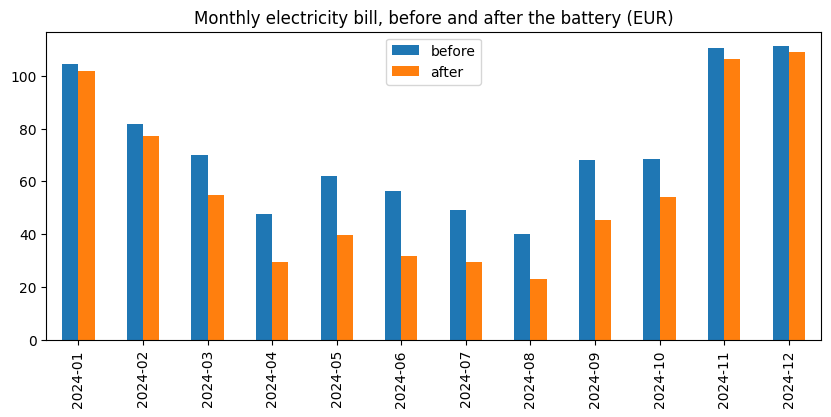

In [9]:
monthly[["before", "after"]].plot.bar(
    figsize=(10, 4), title="Monthly electricity bill, before and after the battery (EUR)"
);

## 7. Caveats the result tells you about

Contract costing is best-effort: a result can be arithmetically valid but still
misleading. Rather than failing, those conditions come back as structured warnings.

The most important one to know about: the Flemish capacity tariff averages the monthly
peak over a **12-month rolling window**, so a simulation shorter than a year has no
history to average against and its absolute capacity cost is overstated. The before/after
delta stays meaningful, which is why the component is reported rather than suppressed.

In [10]:
if cost.warnings:
    for warning in cost.warnings:
        print(f"[{warning.code.value}] {warning.message}")
else:
    print("No warnings: a full 12 months of data on clean billing boundaries.")

No warnings: a full 12 months of data on clean billing boundaries.


In [11]:
# A three-month run, to show the capacity-window warning firing.
short_result = await run_simulation(
    FullSimulationInput.model_validate(build_payload(intervals=96 * 90)), session=None
)
for warning in short_result.cost.warnings:
    print(f"[{warning.code.value}] {warning.message}")

[partial_billing_period] The period 2024-01-01T00:00:00+01:00 to 2024-03-31T00:00:00+01:00 does not align with the P1M billing resolution. Fixed and capacity charges are billed for the whole snapped period, so absolute totals are inflated; the before/after comparison is unaffected.
[capacity_window_incomplete] The capacity tariff averages over 12 billing periods, but the simulation spans only 90 days 00:00:00. With no prior history the early periods are not averaged down, so the absolute capacity cost is overstated. Supply at least 12 billing periods of data for a steady-state figure; the before/after delta remains meaningful.
